In [5]:
import qiskit
print(qiskit.__version__)

2.4.1


In [ ]:


import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as np
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

from models.LSTMAE_pipeline import (
    LSTMAEConfig,
    train_lstm_ae_latent_pipeline,
    plot_training_history,
    plot_reconstructed_series,
    plot_latent_trajectories,
)

In [ ]:


file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

train_end_idx = 434

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

df_train shape: (434, 17)
df_test shape: (105, 17)


In [ ]:


lstm_config = LSTMAEConfig(
    value_col=4,
    window_size=20,
    latent_dim=6,
    train_window_end=350,
    batch_size=16,
    n_epochs=1500,
    learning_rate=0.001,
    dropout_ratio=0.0,
    use_act=False,
    device="cpu",
    save_path="lstm_ae_encoder_ws20_latent6.pth",
    print_every=50,
)

lstm_results = train_lstm_ae_latent_pipeline(
    df=df_train,
    config=lstm_config,
    fit_scaler_in_train=True,
)

Epoch [50/1500] Train Loss: 0.118881 Val Loss: 0.136885
Epoch [100/1500] Train Loss: 0.079292 Val Loss: 0.085413
Epoch [150/1500] Train Loss: 0.071741 Val Loss: 0.081725
Epoch [200/1500] Train Loss: 0.067427 Val Loss: 0.080061
Epoch [250/1500] Train Loss: 0.065380 Val Loss: 0.078640
Epoch [300/1500] Train Loss: 0.063258 Val Loss: 0.078257
Epoch [350/1500] Train Loss: 0.060881 Val Loss: 0.078175
Epoch [400/1500] Train Loss: 0.059502 Val Loss: 0.078927
Epoch [450/1500] Train Loss: 0.058827 Val Loss: 0.078784
Epoch [500/1500] Train Loss: 0.057577 Val Loss: 0.079392
Epoch [550/1500] Train Loss: 0.056864 Val Loss: 0.079460
Epoch [600/1500] Train Loss: 0.056198 Val Loss: 0.079265
Epoch [650/1500] Train Loss: 0.055649 Val Loss: 0.077596
Epoch [700/1500] Train Loss: 0.055337 Val Loss: 0.076437
Epoch [750/1500] Train Loss: 0.054607 Val Loss: 0.075325
Epoch [800/1500] Train Loss: 0.054261 Val Loss: 0.074865
Epoch [850/1500] Train Loss: 0.053928 Val Loss: 0.076214
Epoch [900/1500] Train Loss: 0.0

In [5]:
print("X_train shape:", lstm_results["X_train"].shape)
print("X_val shape:", lstm_results["X_val"].shape)

print("z_train shape:", lstm_results["z_train"].shape)
print("z_val shape:", lstm_results["z_val"].shape)

print("y_train shape:", lstm_results["y_train"].shape)
print("y_val shape:", lstm_results["y_val"].shape)

print("Model:")
print(lstm_results["model"])
print("decoder.use_act:", lstm_results["model"].decoder.use_act)

X_train shape: (350, 20, 1)
X_val shape: (64, 20, 1)
z_train shape: (350, 6)
z_val shape: (64, 6)
y_train shape: (350, 1)
y_val shape: (64, 1)
Model:
LSTMAE(
  (encoder): Encoder(
    (lstm_enc): LSTM(1, 6, batch_first=True)
  )
  (decoder): Decoder(
    (act): Tanh()
    (lstm_dec): LSTM(6, 6, batch_first=True)
    (fc): Linear(in_features=6, out_features=1, bias=True)
  )
)
decoder.use_act: False


In [ ]:


X_train = lstm_results["X_train"]
X_val = lstm_results["X_val"]

X_train_reconstructed = lstm_results["X_train_reconstructed"]
X_val_reconstructed = lstm_results["X_val_reconstructed"]

train_mse = np.mean((X_train - X_train_reconstructed) ** 2)
val_mse = np.mean((X_val - X_val_reconstructed) ** 2)

train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

train_corr = np.corrcoef(
    X_train.reshape(-1),
    X_train_reconstructed.reshape(-1)
)[0, 1]

val_corr = np.corrcoef(
    X_val.reshape(-1),
    X_val_reconstructed.reshape(-1)
)[0, 1]

print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Train Corr:", train_corr)

print("Val MSE:", val_mse)
print("Val RMSE:", val_rmse)
print("Val Corr:", val_corr)

Train MSE: 0.04946232
Train RMSE: 0.22240126
Train Corr: 0.8465656055375702
Val MSE: 0.07247876
Val RMSE: 0.2692188
Val Corr: 0.7873548259457559


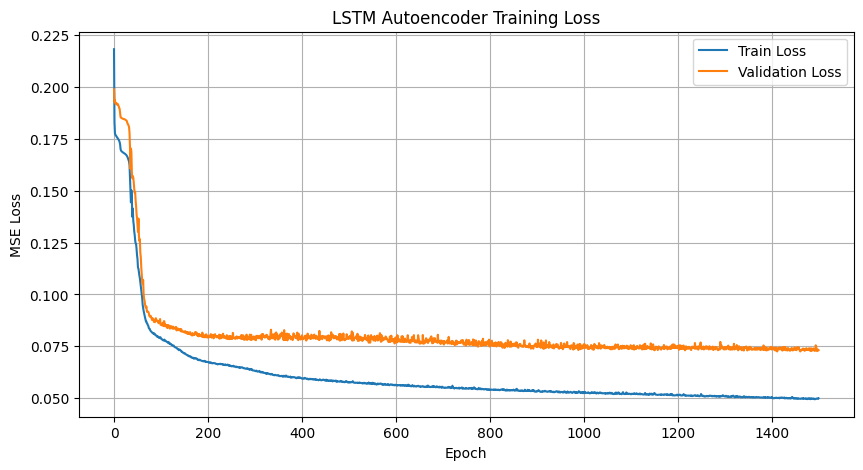

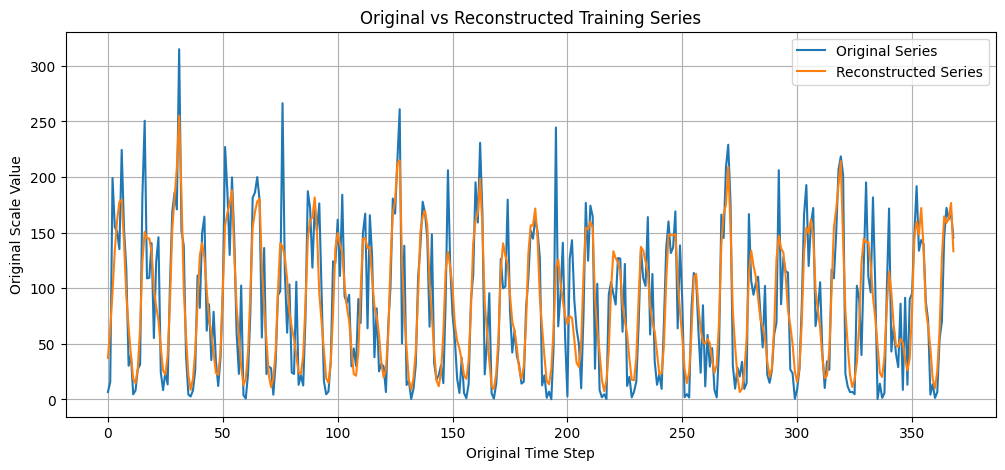

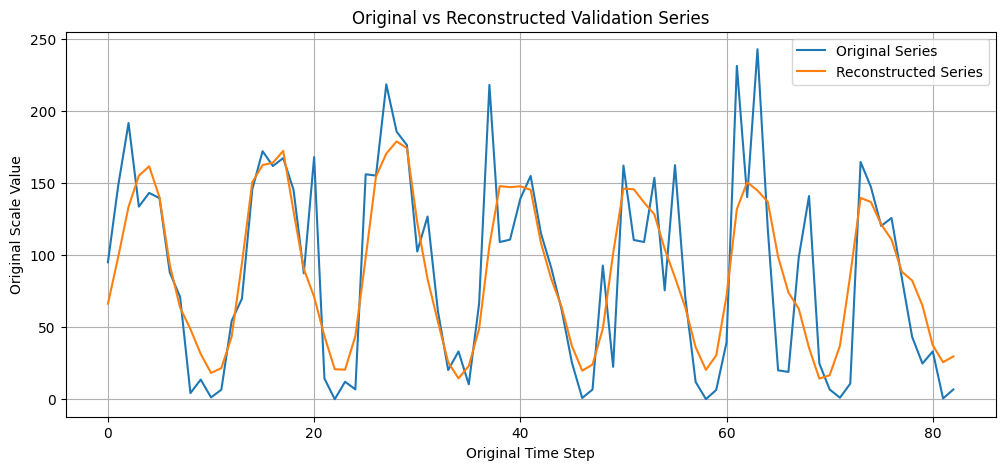

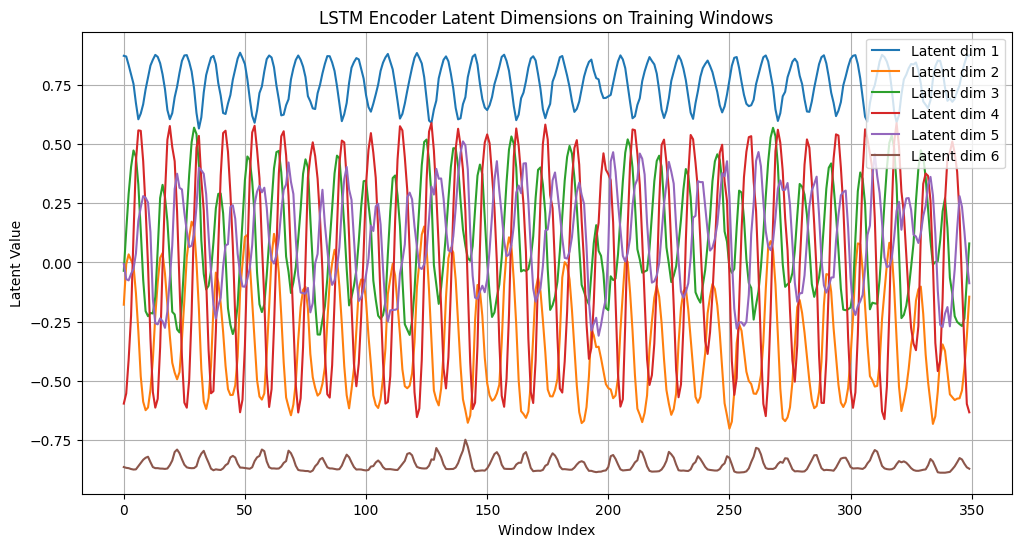

In [ ]:


plot_training_history(lstm_results["history"])

plot_reconstructed_series(
    original_windows=lstm_results["X_train"],
    reconstructed_windows=lstm_results["X_train_reconstructed"],
    scaler=lstm_results["scaler"],
    title="Original vs Reconstructed Training Series",
)

plot_reconstructed_series(
    original_windows=lstm_results["X_val"],
    reconstructed_windows=lstm_results["X_val_reconstructed"],
    scaler=lstm_results["scaler"],
    title="Original vs Reconstructed Validation Series",
)

plot_latent_trajectories(
    lstm_results["z_train"],
    title="LSTM Encoder Latent Dimensions on Training Windows",
)

In [ ]:


z_train = lstm_results["z_train"]
z_val = lstm_results["z_val"]

y_train = lstm_results["y_train"].reshape(-1)
y_val = lstm_results["y_val"].reshape(-1)

print("z_train shape:", z_train.shape)
print("z_val shape:", z_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

# Map LSTM latent vectors to quantum rotation angles.
# z has shape: (num_windows, 6)
# angles will also have shape: (num_windows, 6)
X_qnn_train = np.pi * np.tanh(z_train)
X_qnn_val = np.pi * np.tanh(z_val)

X_qnn_train_torch = torch.tensor(X_qnn_train, dtype=torch.float64)
X_qnn_val_torch = torch.tensor(X_qnn_val, dtype=torch.float64)

y_qnn_train_torch = torch.tensor(y_train, dtype=torch.float64)
y_qnn_val_torch = torch.tensor(y_val, dtype=torch.float64)

print("X_qnn_train_torch:", X_qnn_train_torch.shape)
print("X_qnn_val_torch:", X_qnn_val_torch.shape)
print("y_qnn_train_torch:", y_qnn_train_torch.shape)
print("y_qnn_val_torch:", y_qnn_val_torch.shape)

z_train shape: (350, 6)
z_val shape: (64, 6)
y_train shape: (350,)
y_val shape: (64,)
X_qnn_train_torch: torch.Size([350, 6])
X_qnn_val_torch: torch.Size([64, 6])
y_qnn_train_torch: torch.Size([350])
y_qnn_val_torch: torch.Size([64])


In [ ]:

# QNN DATALOADERS


from torch.utils.data import TensorDataset, DataLoader

qnn_batch_size = 32

qnn_train_dataset = TensorDataset(X_qnn_train_torch, y_qnn_train_torch)
qnn_val_dataset = TensorDataset(X_qnn_val_torch, y_qnn_val_torch)

qnn_train_loader = DataLoader(
    qnn_train_dataset,
    batch_size=qnn_batch_size,
    shuffle=True,
)

qnn_val_loader = DataLoader(
    qnn_val_dataset,
    batch_size=qnn_batch_size,
    shuffle=False,
)

In [10]:
# =========================
# QUANTUM CIRCUIT SETUP
# =========================

import pennylane as qml

n_ansatz_layers = 1
n_layers = 5
n_qubits = 6

dev_parallel = qml.device("default.qubit", wires=n_qubits)


def S(x):
    for w in range(n_qubits):
        qml.RY(x[w], wires=w)


def W(theta):
    for l in range(n_ansatz_layers):
        for w in range(n_qubits):
            qml.Rot(
                theta[l, w, 0],
                theta[l, w, 1],
                theta[l, w, 2],
                wires=w,
            )

        for w in range(n_qubits - 1):
            qml.CNOT(wires=[w, w + 1])

        qml.CNOT(wires=[n_qubits - 1, 0])


@qml.qnode(dev_parallel, interface="torch")
def circuit_parallel(params, x):
    for l in range(n_layers):
        S(x)
        W(params[l])

    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [ ]:

# HYBRID QNN MODEL


class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.q_params = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_ansatz_layers,
                n_qubits,
                3,
                dtype=torch.float64,
            )
        )

        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 1),
            nn.Tanh(),
        ).double()

    def forward(self, x_batch):
        q_outputs = []

        for x in x_batch:
            q_out = circuit_parallel(self.q_params, x)

            # q_out is a list of n_qubits scalar tensors.
            q_out = torch.stack(q_out)

            q_outputs.append(q_out)

        # Shape: (batch_size, n_qubits)
        q_outputs = torch.stack(q_outputs)

        y_pred = self.classical(q_outputs)

        return y_pred.squeeze(-1)

In [ ]:

# INITIALIZE QNN MODEL


device = torch.device("cpu")

hybrid_model = HybridModel().to(device)

criterion = nn.MSELoss()


optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.005)

print(hybrid_model)

HybridModel(
  (classical): Sequential(
    (0): Linear(in_features=6, out_features=1, bias=True)
    (1): Tanh()
  )
)


In [ ]:

# QNN TRAINING LOOP


n_epochs_qnn = 200

train_losses_qnn = []
val_losses_qnn = []

best_val_loss_qnn = float("inf")
best_qnn_state = None

for epoch in range(n_epochs_qnn):
    hybrid_model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in qnn_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = hybrid_model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = total_train_loss / len(qnn_train_loader.dataset)

    hybrid_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in qnn_val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = hybrid_model(X_batch)

            loss = criterion(y_pred, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = total_val_loss / len(qnn_val_loader.dataset)

    train_losses_qnn.append(avg_train_loss)
    val_losses_qnn.append(avg_val_loss)

    if avg_val_loss < best_val_loss_qnn:
        best_val_loss_qnn = avg_val_loss
        best_qnn_state = copy.deepcopy(hybrid_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{n_epochs_qnn}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {avg_val_loss:.6f}"
        )

hybrid_model.load_state_dict(best_qnn_state)

print("Best QNN validation loss:", best_val_loss_qnn)

Epoch [10/200] Train Loss: 0.107657 Val Loss: 0.136092
Epoch [20/200] Train Loss: 0.079082 Val Loss: 0.133140
Epoch [30/200] Train Loss: 0.070023 Val Loss: 0.134812
Epoch [40/200] Train Loss: 0.065992 Val Loss: 0.132401
Epoch [50/200] Train Loss: 0.063210 Val Loss: 0.134727
Epoch [60/200] Train Loss: 0.061195 Val Loss: 0.136212
Epoch [70/200] Train Loss: 0.059106 Val Loss: 0.140218
Epoch [80/200] Train Loss: 0.057784 Val Loss: 0.142784
Epoch [90/200] Train Loss: 0.056321 Val Loss: 0.147426
Epoch [100/200] Train Loss: 0.056112 Val Loss: 0.147113
Epoch [110/200] Train Loss: 0.055940 Val Loss: 0.150755
Epoch [120/200] Train Loss: 0.054690 Val Loss: 0.151733
Epoch [130/200] Train Loss: 0.054356 Val Loss: 0.150575
Epoch [140/200] Train Loss: 0.053504 Val Loss: 0.151365
Epoch [150/200] Train Loss: 0.054005 Val Loss: 0.151611
Epoch [160/200] Train Loss: 0.054108 Val Loss: 0.151361
Epoch [170/200] Train Loss: 0.052197 Val Loss: 0.152657
Epoch [180/200] Train Loss: 0.052031 Val Loss: 0.152031
E

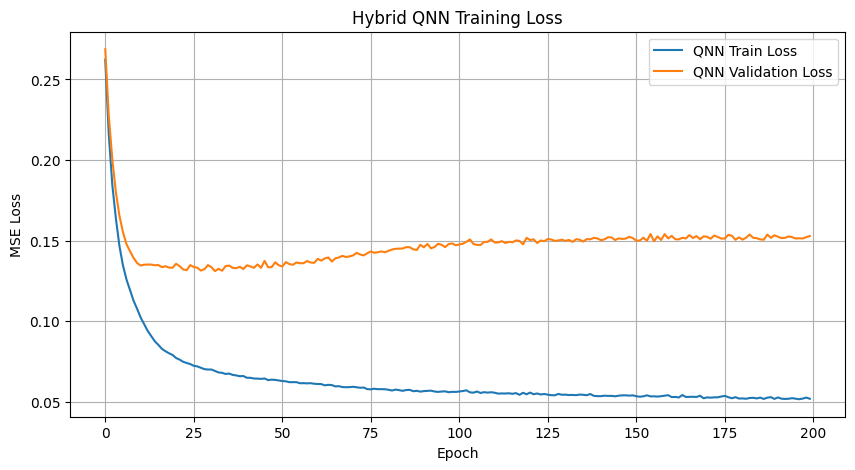

In [15]:
# =========================
# PLOT QNN TRAINING LOSS
# =========================

plt.figure(figsize=(10, 5))
plt.plot(train_losses_qnn, label="QNN Train Loss")
plt.plot(val_losses_qnn, label="QNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Hybrid QNN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

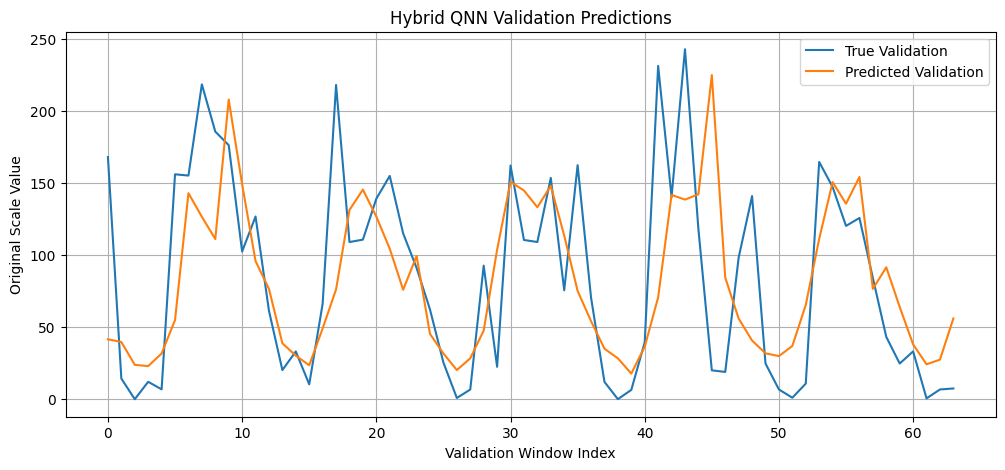

In [ ]:

# VALIDATION PREDICTIONS


hybrid_model.eval()

with torch.no_grad():
    y_pred_val_scaled = hybrid_model(X_qnn_val_torch.to(device)).cpu().numpy()

y_val_scaled = y_qnn_val_torch.cpu().numpy()

scaler = lstm_results["scaler"]

y_pred_val_original = scaler.inverse_transform(
    y_pred_val_scaled.reshape(-1, 1)
).flatten()

y_val_original = scaler.inverse_transform(
    y_val_scaled.reshape(-1, 1)
).flatten()

plt.figure(figsize=(12, 5))
plt.plot(y_val_original, label="True Validation")
plt.plot(y_pred_val_original, label="Predicted Validation")
plt.xlabel("Validation Window Index")
plt.ylabel("Original Scale Value")
plt.title("Hybrid QNN Validation Predictions")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

# VALIDATION METRICS


val_mse_scaled = np.mean((y_pred_val_scaled - y_val_scaled) ** 2)
val_rmse_scaled = np.sqrt(val_mse_scaled)

val_mse_original = np.mean((y_pred_val_original - y_val_original) ** 2)
val_rmse_original = np.sqrt(val_mse_original)

val_mae_original = np.mean(np.abs(y_pred_val_original - y_val_original))

print("Validation MSE scaled:", val_mse_scaled)
print("Validation RMSE scaled:", val_rmse_scaled)

print("Validation MSE original:", val_mse_original)
print("Validation RMSE original:", val_rmse_original)
print("Validation MAE original:", val_mae_original)

Validation MSE scaled: 0.1310727024613407
Validation RMSE scaled: 0.3620396421130436
Validation MSE original: 3246.5362621550776
Validation RMSE original: 56.97838416588415
Validation MAE original: 40.13785127891383
